In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from lxml import etree
from collections import Counter

print("pandas:", pd.__version__)

CORPUS = Path("../bullinger-korpus-tei/data/letters")

pandas: 3.0.1


## 1. Parse TEI-XML

In [2]:
NS = {"tei": "http://www.tei-c.org/ns/1.0"}

def parse_letter(path):
    tree = etree.parse(str(path))
    root = tree.getroot()
    letter_id = root.get("{http://www.w3.org/XML/1998/namespace}id", path.stem)

    sent = root.find(".//tei:correspAction[@type='sent']", NS)
    sender_ref = sender_cert = date_when = date_cert = place_ref = place_cert = None
    if sent is not None:
        s = sent.find("tei:persName", NS)
        if s is not None:
            sender_ref, sender_cert = s.get("ref"), s.get("cert")
        p = sent.find("tei:placeName", NS)
        if p is not None:
            place_ref, place_cert = p.get("ref"), p.get("cert")
        d = sent.find("tei:date", NS)
        if d is not None:
            date_when = d.get("when")
            if not date_when:
                nb, na = d.get("notBefore"), d.get("notAfter")
                date_when = f"{nb}/{na}" if nb or na else None
            date_cert = d.get("cert")

    received = root.find(".//tei:correspAction[@type='received']", NS)
    recipient_ref = recipient_cert = None
    if received is not None:
        r = received.find("tei:persName", NS)
        if r is not None:
            recipient_ref, recipient_cert = r.get("ref"), r.get("cert")

    lang_els = root.findall(".//tei:langUsage/tei:language", NS)
    language = None
    if lang_els:
        language = max(lang_els, key=lambda el: int(el.get("usage", 0))).get("ident")

    return dict(
        letter_id=letter_id,
        sender_ref=sender_ref, sender_cert=sender_cert,
        recipient_ref=recipient_ref, recipient_cert=recipient_cert,
        date_when=date_when, date_cert=date_cert,
        place_ref=place_ref, place_cert=place_cert,
        language=language
    )

def normalise_date_str(s):
    """Normalise date_when to a plain ISO string."""
    if not s or isinstance(s, float): return None
    s = str(s).strip()
    if "/" in s: s = s.split("/")[0].strip()   # range -> take start
    if not s: return None
    if len(s) == 4 and s.isdigit(): return f"{s}-01-01"   # year only
    if len(s) == 7: return f"{s}-01"                       # year-month
    return s

def date_precision(s):
    if not s or (isinstance(s, float)): return "missing"
    s = str(s).strip()
    if "/" in s: return "range"
    if len(s) == 4 and s.isdigit(): return "year_only"
    if len(s) == 7: return "year_month"
    return "full"

files = sorted(CORPUS.glob("*.xml"))
records = [parse_letter(f) for f in files]
df = pd.DataFrame(records)

df["date_precision"] = df["date_when"].apply(date_precision)
df["date_parsed"] = pd.to_datetime(
    df["date_when"].apply(normalise_date_str),
    format="mixed", dayfirst=False, errors="coerce"
).astype("datetime64[us]")
df["year"]  = df["date_parsed"].dt.year.astype("Int64")
df["month"] = df["date_parsed"].dt.month.astype("Int64")

print(f"Parsed: {len(df)} letters")
print(f"date_parsed dtype: {df['date_parsed'].dtype}")
print(f"Dates resolved: {df['date_parsed'].notna().sum()} / {len(df)}")
df[["letter_id", "date_when", "date_parsed", "year"]].head(8)

Parsed: 13114 letters
date_parsed dtype: datetime64[us]
Dates resolved: 13114 / 13114


,letter_id,date_when,date_parsed,year
0,file1,1547,1547-01-01,1547
1,file10,1548-01-12,1548-01-12,1548
2,file100,1548-04-23,1548-04-23,1548
3,file1000,1550-08-22,1550-08-22,1550
4,file10000,1575-08-16,1575-08-16,1575
5,file10001,1575-08-17,1575-08-17,1575
6,file10002,1575-08-18,1575-08-18,1575
7,file10003,1575-08-19,1575-08-19,1575


## 2. Missing values & cert distributions

In [3]:
for col in ["sender_ref", "recipient_ref", "date_when", "place_ref"]:
    n = df[col].isna().sum()
    print(f"  {col:20s}: {n:5d}  ({n/len(df)*100:.1f}%)")


  sender_ref          :   340  (2.6%)
  recipient_ref       :   466  (3.6%)
  date_when           :     0  (0.0%)
  place_ref           :   607  (4.6%)


## 3. Temporal coverage

  Earliest : 1504-01-01
  Latest   : 1575-11-20
  date_precision distribution:
date_precision
full          12244
range           614
year_month      255
year_only         1


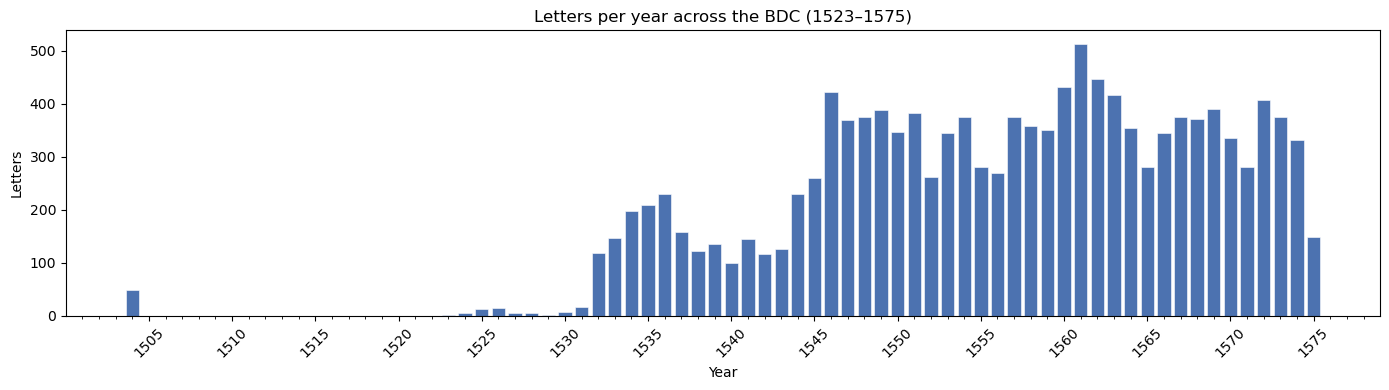

In [4]:
print(f"  Earliest : {df['date_parsed'].min().date()}")
print(f"  Latest   : {df['date_parsed'].max().date()}")
print(f"  date_precision distribution:")
print(df["date_precision"].value_counts().to_string())

# Letters per year
yearly = df.groupby("year", dropna=True).size().reset_index(name="count")
yearly["year"] = yearly["year"].astype(int)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(yearly["year"], yearly["count"], width=0.8, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Letters")
ax.set_title("Letters per year across the BDC (1523–1575)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Correspondent network overview

In [6]:
BULLINGER = "p495"

print("Top 25 senders")
print(df["sender_ref"].value_counts().head(25).to_string())
print()
print("Top 25 recipients")
print(df["recipient_ref"].value_counts().head(25).to_string())

# Bullinger focus
bull_recv = (df["recipient_ref"] == BULLINGER).sum()
bull_sent = (df["sender_ref"] == BULLINGER).sum()
print(f"\nBullinger (p495) as recipient : {bull_recv} ({bull_recv/len(df)*100:.1f}%)")
print(f"Bullinger (p495) as sender    : {bull_sent} ({bull_sent/len(df)*100:.1f}%)")

Top 25 senders
sender_ref
p495     2797
p8018     672
p8055     605
p8009     434
p8418     348
p8033     294
p8016     225
p1278     193
p3375     165
p8049     160
p1010     151
p3740     147
p3099     141
p1918     141
p8075     137
p540      125
p8354     115
p8109     115
p8417     114
p4079     113
p1391     110
p629      105
p8359      98
p252       96
p8432      81

Top 25 recipients
recipient_ref
p495     9828
p8009     309
p8418     212
p477      212
p8016     208
p8033     175
p540      174
p8055     166
p8049      95
p8109      76
p8018      67
p1010      49
p3590      44
p252       36
p487       31
p8011      29
p850       29
p8432      27
p3067      26
p467       23
p1753      18
p6831      18
p2095      16
p1754      16
p714       15

Bullinger (p495) as recipient : 9828 (74.9%)
Bullinger (p495) as sender    : 2797 (21.3%)


## 5. Temporal window analysis

In [7]:
# Only use letters with high-cert sender, recipient, and a fully parsed date
df_dated = df[
    df["date_parsed"].notna() &
    df["sender_ref"].notna() &
    df["recipient_ref"].notna()
].copy().sort_values("date_parsed")

print(f"Letters with sender + recipient + date: {len(df_dated)}")

# Compute within-pair gaps (undirected: sort pair so A < B)
df_dated["pair"] = df_dated.apply(
    lambda r: tuple(sorted([r.sender_ref, r.recipient_ref])), axis=1
)

gap_records = []
for pair, grp in df_dated.groupby("pair"):
    grp = grp.sort_values("date_parsed")
    gaps = grp["date_parsed"].diff().dt.days.dropna()
    for g in gaps:
        if g >= 0:   # skip any ordering artefacts
            gap_records.append({"pair": pair, "gap_days": g,
                                 "n_letters": len(grp)})

gaps_df = pd.DataFrame(gap_records)
print(f"Within-pair gaps computed     : {len(gaps_df)}")
print(f"Unique pairs                  : {gaps_df['pair'].nunique()}")

g = gaps_df["gap_days"]
print(f"Gap distribution (all pairs)")
print(f"  median : {g.median():.0f} days")
print(f"  mean   : {g.mean():.0f} days")
print(f"  p25    : {g.quantile(0.25):.0f} days")
print(f"  p75    : {g.quantile(0.75):.0f} days")
print(f"  p90    : {g.quantile(0.90):.0f} days")
print(f"  p95    : {g.quantile(0.95):.0f} days")
print(f"  max    : {g.max():.0f} days")

# Fraction of gaps within candidate windows
print(f"\nFraction of within-pair gaps within window")
for w in [7, 14, 30, 60, 90, 180]:
    frac = (g <= w).mean()
    print(f"  <= {w:3d} days : {frac*100:.1f}%")

Letters with sender + recipient + date: 12504
Within-pair gaps computed     : 11499
Unique pairs                  : 534
Gap distribution (all pairs)
  median : 18 days
  mean   : 161 days
  p25    : 6 days
  p75    : 67 days
  p90    : 268 days
  p95    : 653 days
  max    : 22885 days

Fraction of within-pair gaps within window
  <=   7 days : 30.7%
  <=  14 days : 45.2%
  <=  30 days : 61.3%
  <=  60 days : 73.4%
  <=  90 days : 78.7%
  <= 180 days : 86.4%


## 6. Communication density by window (pairs with ≥2 letters)
For each candidate window, how many pairs have ≥1 gap within it? 
This translates directly to graph edge density.

In [10]:
total_pairs = gaps_df["pair"].nunique()

print(f"Total pairs with ≥2 letters: {total_pairs}")
print()
print(f"{'Window':>10}  {'Pairs with ≥1 gap within window':>35}  {'% of all pairs':>15}")
print("-" * 65)
for w in [7, 14, 30, 60, 90, 180, 365]:
    pairs_in_window = gaps_df[gaps_df["gap_days"] <= w]["pair"].nunique()
    print(f"{w:>8}d  {pairs_in_window:>35d}  {pairs_in_window/total_pairs*100:>14.1f}%")

# Also: for pairs with many letters, what window captures most exchanges?
print("Gap distribution for top-10 most active pairs")
top_pairs = gaps_df.groupby("pair")["gap_days"].count().nlargest(10).index
for pair in top_pairs:
    sub = gaps_df[gaps_df["pair"] == pair]["gap_days"]
    print(f"  {pair[0]}<->{pair[1]:10s}  n={len(sub):4d}  "
          f"median={sub.median():.0f}d  "
          f"≤30d={( sub<=30).mean()*100:.0f}%  "
          f"≤60d={(sub<=60).mean()*100:.0f}%")

Total pairs with ≥2 letters: 534

    Window      Pairs with ≥1 gap within window   % of all pairs
-----------------------------------------------------------------
       7d                                  200            37.5%
      14d                                  249            46.6%
      30d                                  301            56.4%
      60d                                  347            65.0%
      90d                                  377            70.6%
     180d                                  426            79.8%
     365d                                  462            86.5%
Gap distribution for top-10 most active pairs
  p495<->p8055       n= 770  median=6d  ≤30d=87%  ≤60d=94%
  p495<->p8009       n= 740  median=4d  ≤30d=99%  ≤60d=100%
  p495<->p8018       n= 735  median=10d  ≤30d=88%  ≤60d=98%
  p495<->p8418       n= 556  median=8d  ≤30d=90%  ≤60d=98%
  p495<->p8033       n= 451  median=10d  ≤30d=84%  ≤60d=94%
  p495<->p8016       n= 431  median=4d  ≤30

## 7. Save parsed metadata

In [12]:
out = Path("bdc_metadata.csv")
df.to_csv(out, index=False)
print(f"Saved {len(df)} rows")
df.dtypes

Saved 13114 rows


letter_id                    str
sender_ref                   str
sender_cert                  str
recipient_ref                str
recipient_cert               str
date_when                    str
date_cert                    str
place_ref                    str
place_cert                   str
language                     str
date_precision               str
date_parsed       datetime64[us]
year                       Int64
month                      Int64
dtype: object